Lap 03: 3.1.3_Xây dựng mô hình phân cụm K-means trên tập dữ liệu chim cánh cụt.
Nguyễn Thị Thu Thảo

In [3]:
# Import các gói thư viện và nạp dữ liệu vào notebook 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
import warnings 
warnings.filterwarnings('ignore') 
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score 
from sklearn.preprocessing import StandardScaler
 
url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"
df = pd.read_csv(url)

numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_clean = df.dropna(subset=numeric_features) 
# Data for cluster 
X = df_clean[numeric_features] 

In [4]:
# Xây dựng mô hình K-Means:  We will create K-Means Models `iteratively between k values of 3 to 10` 
km_inertias, km_scores = [], []
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
for k in range(3, 10): 
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled) 
    km_inertias.append(km.inertia_) 
    current_score = silhouette_score(X_scaled, km.labels_)
    km_scores.append(current_score) 
    print(f"Processing K-Means with k = {k}, Inertia = {km.inertia_:.2f}, Silhouette Score = {current_score:.4f}") 


print("\nDanh sách km_inertias thu được:")
print(km_inertias)

Processing K-Means with k = 3, Inertia = 379.39, Silhouette Score = 0.4472
Processing K-Means with k = 4, Inertia = 300.40, Silhouette Score = 0.3996
Processing K-Means with k = 5, Inertia = 232.60, Silhouette Score = 0.3789
Processing K-Means with k = 6, Inertia = 204.39, Silhouette Score = 0.3680
Processing K-Means with k = 7, Inertia = 187.03, Silhouette Score = 0.3309
Processing K-Means with k = 8, Inertia = 170.98, Silhouette Score = 0.2961
Processing K-Means with k = 9, Inertia = 159.98, Silhouette Score = 0.2791

Danh sách km_inertias thu được:
[379.39250275551746, 300.3995356267377, 232.60489541912898, 204.39259957010313, 187.02892112980626, 170.98004060500995, 159.97997529752035]


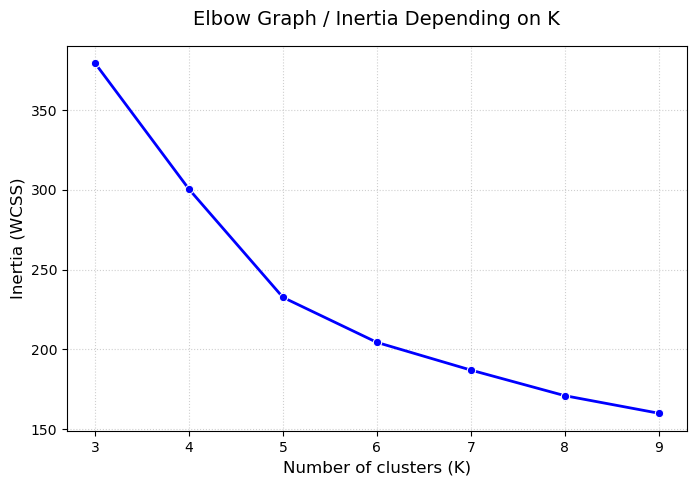

In [7]:
# Tìm số cụm tối ưu cho mô hình K-Mean bằng phương pháp Elbow 
plt.figure(figsize=(8, 5))
sns.lineplot(x=range(3, 10), y=km_inertias, marker='o', color='b', linewidth=2)
plt.title('Elbow Graph / Inertia Depending on K', fontsize=14, pad=15) 
plt.xlabel('Number of clusters (K)', fontsize=12) 
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.xticks(range(3, 10)) 
plt.grid(True, linestyle=':', alpha=0.6) 

plt.show()

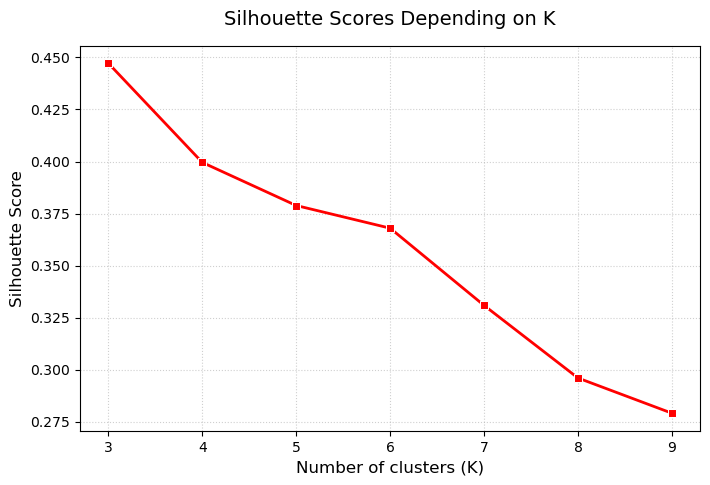

In [11]:
# Tìm số cụm tối ưu bằng phương pháp Silhoutte
plt.figure(figsize=(8, 5))
sns.lineplot(x=range(3, 10), y=km_scores, marker='s', color='r', linewidth=2)
plt.title('Silhouette Scores Depending on K', fontsize=14, pad=15) 
plt.xlabel('Number of clusters (K)', fontsize=12) 
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(range(3, 10)) 
plt.grid(True, linestyle=':', alpha=0.6) # Thêm lưới mờ giúp dóng hàng tìm đỉnh cao nhất
plt.show() 

In [12]:
# Huấn luyện mô hình K-Means với số cụm là 6 trên dữ liệu đã chuẩn hóa (X_scaled)
km = KMeans(n_clusters=6, n_init=10, random_state=42).fit(X_scaled) 

X['Label'] = km.labels_ 
for k in range(6): 
    print(f'Cluster nb : {k}') 
    # Cần thụt lề (indent) các câu lệnh bên trong vòng lặp for
    # Sử dụng .iloc[:, :] hoặc bỏ lọc cột để xem đầy đủ thông tin mô tả của các đặc trưng số
    print(X[X.Label == k].describe().iloc[:, :-1]) 
    print('\n' + '='*50 + '\n')

Cluster nb : 0
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count       32.000000      32.000000          32.000000    32.000000
mean        46.953125      17.765625         193.250000  3588.281250
std          1.922865       0.779002           5.645438   293.063929
min         43.500000      16.400000         178.000000  2700.000000
25%         45.700000      17.250000         190.000000  3400.000000
50%         46.450000      17.850000         193.000000  3600.000000
75%         47.725000      18.225000         196.000000  3718.750000
max         51.500000      19.400000         210.000000  4150.000000


Cluster nb : 1
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count       57.000000      57.000000          57.000000    57.000000
mean        49.792982      15.738596         221.912281  5519.736842
std          2.587943       0.760816           5.657740   291.192776
min         44.400000      14.100000         208.000000  4925.000000
25

In [ ]:
import numpy as np 
import pandas as pd 
import plotly.express as px 
import seaborn as sns 
import plotly.graph_objects as go 
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans 
import warnings
warnings.filterwarnings('ignore')


url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"
penguins = pd.read_csv(url) 

# Xử lý dữ liệu khuyết thiếu (Tập dữ liệu chim cánh cụt có một số dòng bị NaN)
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
penguins = penguins.dropna(subset=numeric_cols)

# Hiển thị dữ liệu đẹp với background gradient
penguins.head().style.background_gradient(cmap=sns.cubehelix_palette(as_cmap=True)) 

# Thiết lập dữ liệu huấn luyện X và nhãn thực tế y để trực quan hóa giống code Iris
X = penguins[numeric_cols].values 

# Nhãn loài thực tế (Species) dùng để đối chiếu khi vẽ đồ thị
y = penguins['species'].values

In [14]:
# Data Distribution => Biểu đồ Pie thể hiện phân phối các loài chim cánh cụt
fig = px.pie(penguins, 
             names='species', 
             color_discrete_sequence=['#491D8B','#7D3AC1','#EB548C'],
             title='Data Distribution (Penguins Species)', 
             template='plotly') 
fig.show() 

# Phân tích biến Độ dài mỏ (thay cho SepalLengthCm) với box-plot 
fig = px.box(data_frame=penguins, x='species', y='bill_length_mm', 
             color='species', 
             color_discrete_sequence=['#29066B','#7D3AC1','#EB548C'], 
             orientation='v') 
fig.show() 
 
# Phân tích biến Độ dài mỏ với histogram 
fig = px.histogram(data_frame=penguins, x='bill_length_mm', 
                   color='species', 
                   color_discrete_sequence=['#491D8B','#7D3AC1','#EB548C'], 
                   nbins=50) 
fig.show() 
 
# Phân tích biến Độ dày mỏ (thay cho SepalWidthCm) với box plot 
fig = px.box(data_frame=penguins, x='species', 
             y='bill_depth_mm', color='species', 
             color_discrete_sequence=['#29066B','#7D3AC1','#EB548C'], 
             orientation='v') 
fig.show() 
 
# Phân tích tương quan 2 biến kích thước Mỏ (Bill Length và Bill Depth)
fig = px.scatter(data_frame=penguins, x='bill_length_mm', y='bill_depth_mm',
                 color='species', size='body_mass_g', # Kích thước chấm chấm đại diện cho cân nặng
                 template='seaborn', 
                 color_discrete_sequence=['#491D8B','#7D3AC1','#EB548C']) 
fig.update_layout(width=800, height=600, 
                  xaxis=dict(color="#BF40BF", title="Bill Length (mm)"), 
                  yaxis=dict(color="#BF40BF", title="Bill Depth (mm)")) 
fig.show() 
 
# Phân tích tương quan 2 biến Cánh và Cân nặng (Flipper Length và Body Mass)
fig = px.scatter(data_frame=penguins, x='flipper_length_mm', y='body_mass_g',
                 color='species', size='bill_length_mm', 
                 template='seaborn', 
                 color_discrete_sequence=['#491D8B','#7D3AC1','#EB548C']) 
fig.update_layout(width=800, height=600, 
                  xaxis=dict(color="#BF40BF", title="Flipper Length (mm)"), 
                  yaxis=dict(color="#BF40BF", title="Body Mass (g)")) 
fig.show()

In [16]:
# Chuẩn hóa dữ liệu trước khi chạy thuật toán khoảng cách K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sse = [] 
# Chạy số lượng cụm i từ 1 đến 8 giống như bạn thiết lập cho Iris
for i in range(1, 9): 
    kmeans = KMeans(n_clusters=i, max_iter=300, n_init=10, random_state=42) 
    kmeans.fit(X_scaled)  # Sử dụng X_scaled thay vì X
    sse.append(kmeans.inertia_) 

# Trực quan hóa đường cong khuỷu tay (Elbow) bằng Plotly
fig = px.line(x=list(range(1, 9)), y=sse, template="seaborn", title='Elbow Method') 
fig.update_layout(width=800, height=600, 
                  title_font_color="#BF40BF",  
                  xaxis=dict(color="#BF40BF", title="Clusters"),  
                  yaxis=dict(color="#BF40BF", title="SSE (Inertia)")) 
fig.show()

# Điểm khuỷu tay gãy rõ nhất trên đồ thị vẫn sẽ là Cluster = 3 (Tương ứng 3 loài chim cánh cụt)

In [17]:
# Huấn luyện mô hình tối ưu với K = 3 cụm
optimal_kmeans = KMeans(n_clusters=3, max_iter=300, n_init=10, random_state=42)
penguins['Cluster_Label'] = optimal_kmeans.fit_predict(X_scaled)

# Biểu đồ scatter biểu thị cụm phân loại thực tế của mô hình K-Means
fig = px.scatter(data_frame=penguins, x='bill_length_mm', y='flipper_length_mm',
                 color='Cluster_Label', symbol='species',
                 title='K-Means Clustering Results vs Actual Species',
                 labels={'Cluster_Label': 'Predicted Cluster', 'species': 'Actual Species'},
                 color_discrete_sequence=['#491D8B','#7D3AC1','#EB548C'],
                 template='seaborn')
fig.update_layout(width=800, height=600)
fig.show()